# **Detecção de Anomalias em Transações em Python**

## **Problema:**

As instituições financeiras enfrentam grandes perdas com transações fraudulentas, mas identificar esses eventos é desafiador devido ao alto desbalanceamento dos dados: a esmagadora maioria das transações é legítima (`Class = 0`), enquanto as fraudes (`Class = 1`) representam apenas uma pequena fração do total. Modelos convencionais tendem a ignorar essa minoria, gerando prejuízos financeiros e falhas de segurança.

## **Objetivo:**

Manipular o conjunto de dados bancários e aplicar técnicas de *Feature Engineering* para destacar padrões de fraude. A meta final é treinar modelos preditivos capazes de identificar com alta precisão e sensibilidade a **Classe 1** (fraudes), garantindo alto desempenho nas métricas de Acurácia, Precisão, Recall, F1-Score, Curva ROC e AUC.

## **Lendo a tabela**


In [17]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### **Estrutura do dataset**

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

### **Verificação de dados nulos**



In [19]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


### **Proporção das classes na coluna target (Class)**




In [20]:
df['Class'].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


## **Feature Engineering**

O processo de preparação de dados para o melhor processamento e previsão.
Iremos utilizar algumas técnicas para maximizar o acerto na previão da classe 1 (fraudes)



### **Normalização**

 A normalização de tabelas númericas são responsáveis pelo ajuste de escala dos números, com intuito de torna-los menos "distantes" mantendo a integridade dos seus valores reais, tornando mais fácil o processamento dos mesmos



#### **Range (Amplitude)**

A diferença entre menor e o maior valor é importante para determinar a escala que iremos utilizar para a normalização

In [21]:
df['Amount'].max() - df['Amount'].min()

25691.16

#### **Escala Logarítmica ( log (x + 1) )**

A amplitude da coluna Amount é de 25.691,16.

Em teoria para uma amplitude tão grande e valores que destoam muito da média (outliers), a escala logarítmica é a melhor para suavizar a destribuição dos dados.

Vamos ver isso na prática?

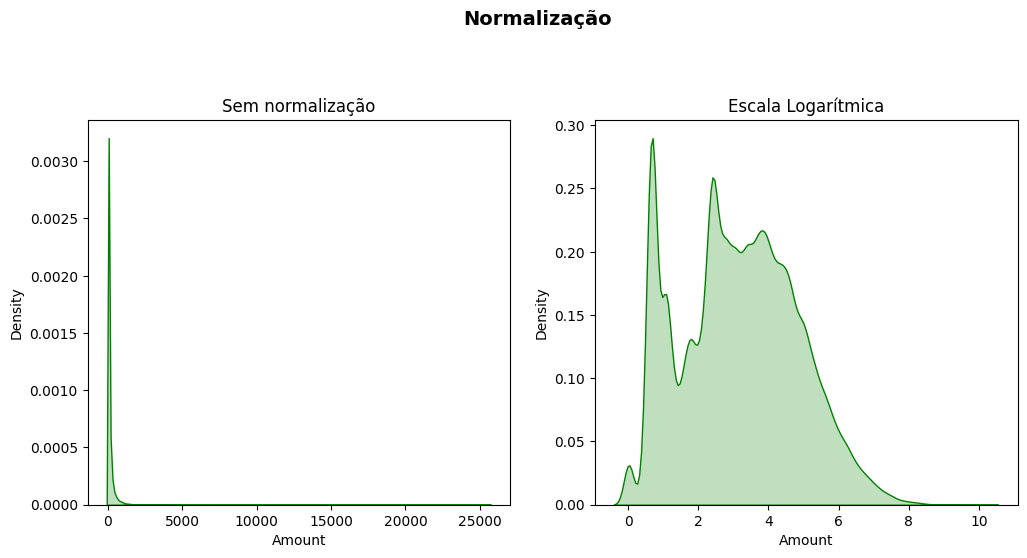

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

array = df['Amount']

plt.figure(figsize=(12,5))
plt.suptitle('Normalização', fontsize=14, weight='bold', y=1.1)

plt.subplot(1, 2, 1)
sns.kdeplot(array, color='green', fill=True)
plt.title('Sem normalização')

plt.subplot(1, 2, 2)
sns.kdeplot(np.log1p(array), color='green', fill=True)
plt.title('Escala Logarítmica')

plt.show()

#### **Escala Padrão ou Z-Score ( z = (x - μ) / σ )**

Converte cada valor bruto subtraindo a média do conjunto e dividindo pelo desvio padrão. O novo conjunto de dados terá sempre média = 0 e desvio padrão = 1.
Fazendo os dados ficarem mais uniformente destribuidos e deixando em evidência os dados que destoam da média, já que os dados acima da média irão ficar positivos e os dados abaixo da média irão ficar negativos

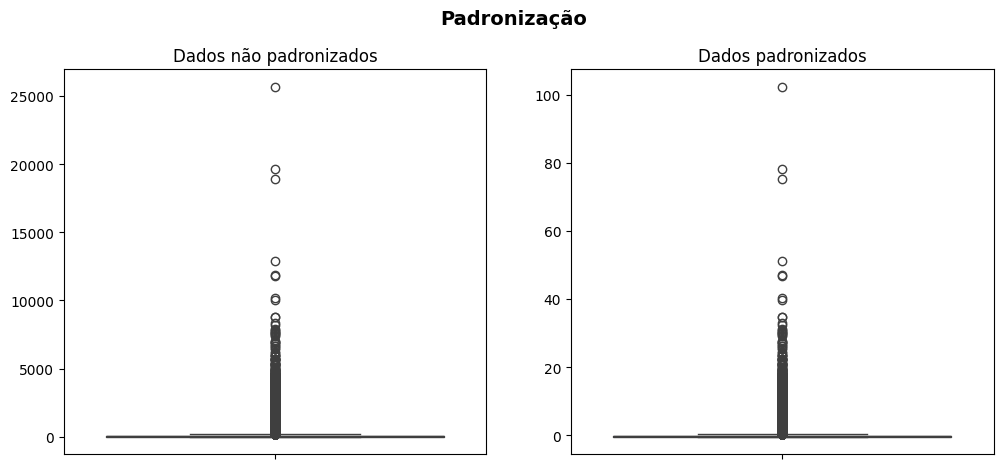

In [23]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

dataset_exemplo = {}
x = df[['Amount']]

scaler = StandardScaler()
dados_padronizados = scaler.fit_transform(x)

dataset_exemplo['Dados não padronizados'] = df['Amount'].values
dataset_exemplo['Dados padronizados'] = dados_padronizados.flatten()


plt.figure(figsize=(12,5))
plt.suptitle('Padronização', fontsize=14, weight='bold', y=1)

plt.subplot(1,2,1)
sns.boxplot(dataset_exemplo['Dados não padronizados'])
plt.title('Dados não padronizados')

plt.subplot(1,2,2)
sns.boxplot(dataset_exemplo['Dados padronizados'])
plt.title('Dados padronizados')

plt.show()


 A diferença fica mais visível quando colocados lado a lado

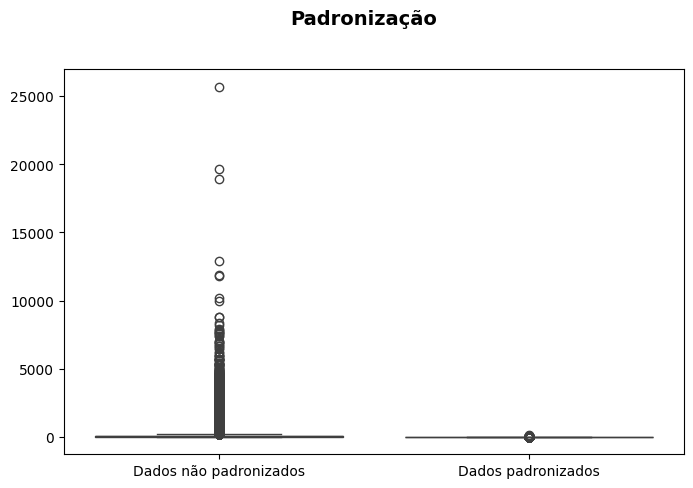

In [24]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

dataset_exemplo = {}
x = df[['Amount']]
scaler = StandardScaler()
dados_padronizados = scaler.fit_transform(x)

dataset_exemplo['Dados não padronizados'] = df['Amount'].values
dataset_exemplo['Dados padronizados'] = dados_padronizados.flatten()

plt.figure(figsize=(8,5))
plt.suptitle('Padronização', fontsize=14, weight='bold', y=1)

sns.boxplot(dataset_exemplo)

plt.show()

### **Criando variáveis para ajudar o modelo**

In [25]:
import numpy as np

df['Amount_log'] = np.log1p(df['Amount'])

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

In [27]:
from  sklearn.model_selection import train_test_split

x = df.drop('Class', axis = 1)
y = df['Class']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, stratify = y, test_size = 0.2, random_state = 42
  )

### **Regressão Logística**

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 1000)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.72      0.77        98

    accuracy                           1.00     56962
   macro avg       0.91      0.86      0.88     56962
weighted avg       1.00      1.00      1.00     56962



Accuracy pode ser alta mesmo sem detectar fraudes.

Por isso usamos:


*   Recall (Mais Importante)
*   Precision
*   F1-Score

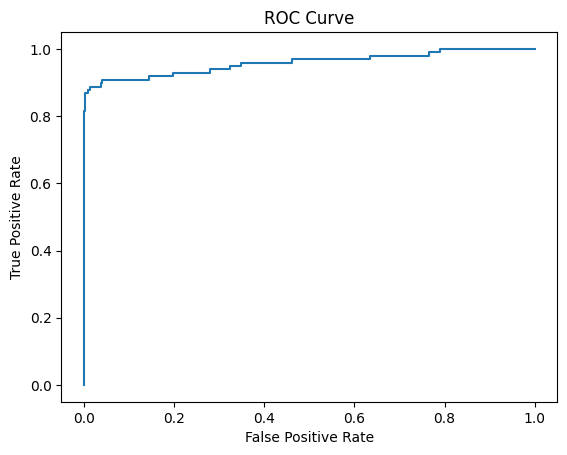

AUC: 0.9584574509319765


In [30]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score (y_test, y_probs))

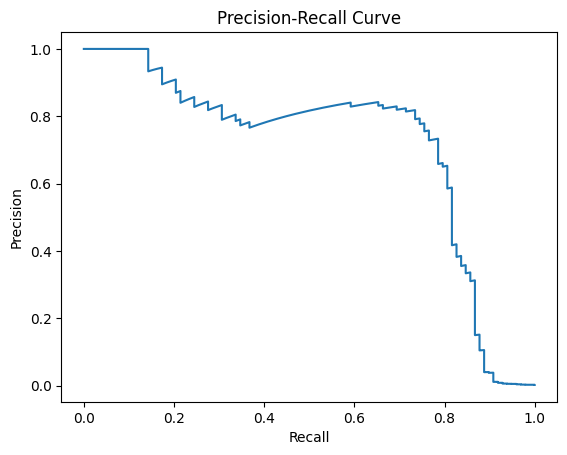

In [31]:

from sklearn.metrics import precision_recall_curve

precisions, recalls, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recalls, precisions)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

### **Balanceamento de Dados**

In [32]:

# Undersampling

fraudes = df [df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [33]:
# Oversampling

from imblearn.over_sampling import SMOTE

smote = SMOTE()

x_res, y_res = smote.fit_resample(x, y)

In [34]:

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.72      0.77        98

    accuracy                           1.00     56962
   macro avg       0.91      0.86      0.88     56962
weighted avg       1.00      1.00      1.00     56962



In [35]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline ([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

In [36]:
threshold = 0.3

y_pred_custom = (y_probs > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.74      0.76        98

    accuracy                           1.00     56962
   macro avg       0.89      0.87      0.88     56962
weighted avg       1.00      1.00      1.00     56962



### **Modelo Avançado - XGBoot**

In [37]:

from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight = 10, # ajuda com desbalanceamento
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb.fit(x_train, y_train)

y_pred_xgb = xgb.predict(x_test)

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [21:59:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [38]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962



### **Importância das Variáveis**

Ajuda a entender quais variáveis influenciam mais o modelo.

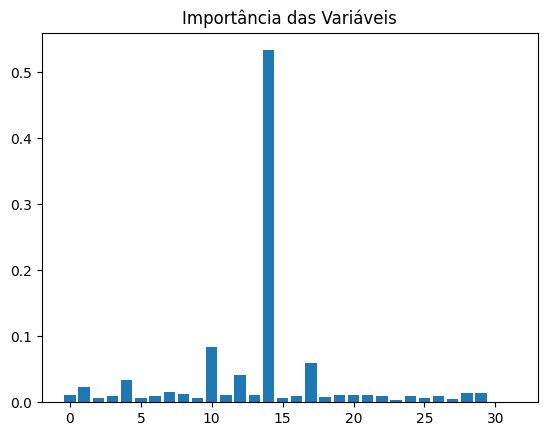

In [39]:

import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das Variáveis")
plt.show()

### **Ajuste de Hiperparâmetros**

Testamos várias combinações para melhorar o modelo.

In [40]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    cv=3,
    scoring="recall"
)

grid.fit(x_train, y_train)

print("Melhor Modelo:", grid.best_params_)

Melhor Modelo: {'max_depth': 3, 'n_estimators': 100}


### **Explicabilidade (SHAP)**

SHAP mostra como cada variável influencia a decisão do modelo.

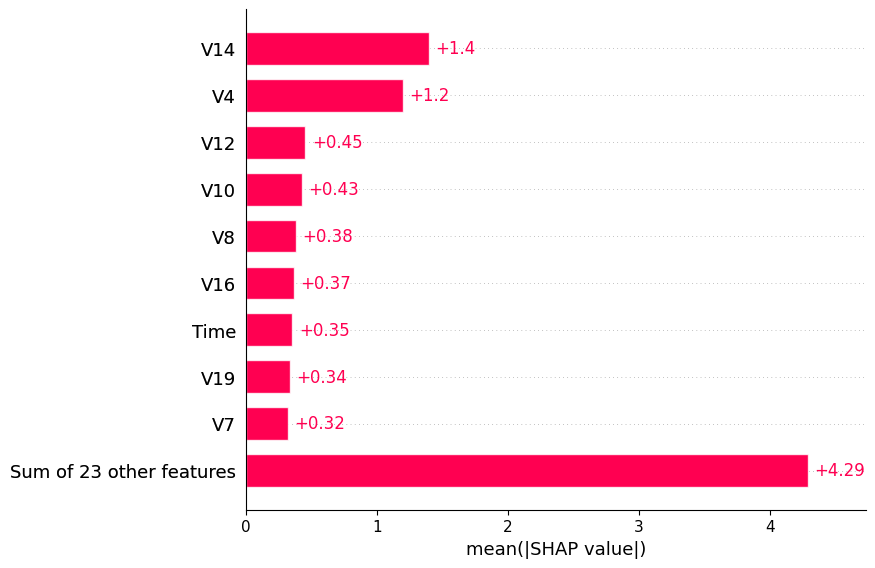

In [41]:
import shap

explainer = shap.Explainer(xgb)

shap_values = explainer(x_test[:100])

shap.plots.bar(shap_values)